In [1]:
import pandas as pd 
from sklearn.datasets import load_iris

In [2]:
iris = load_iris(as_frame=True)
df = iris.frame

In [3]:
df

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   target             150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB


In [5]:
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


In [6]:
# Class balance
print(df['target'].value_counts())

target
0    50
1    50
2    50
Name: count, dtype: int64


In [7]:
#Missing values and duplicates
print(df.isnull().sum())
print("Duplicates:", df.duplicated().sum())

sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
target               0
dtype: int64
Duplicates: 1


In [8]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np

In [9]:

X = df.drop(columns="target").values
y = df["target"].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,        # 20% for testing
    stratify=y,           # keep the same class proportions in both sets
    random_state=42       # same split every time you run it
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # fit + transform on train
X_test_scaled  = scaler.transform(X_test)        # only transform on test

In [10]:
print("Train shape:", X_train_scaled.shape, "| Test shape:", X_test_scaled.shape)
print("Train per class:", np.bincount(y_train))
print("Test per class: ", np.bincount(y_test))
print("Train means:", X_train_scaled.mean(axis=0).round(2))
print("Train stds: ", X_train_scaled.std(axis=0).round(2))

Train shape: (120, 4) | Test shape: (30, 4)
Train per class: [40 40 40]
Test per class:  [10 10 10]
Train means: [-0. -0.  0.  0.]
Train stds:  [1. 1. 1. 1.]


In [11]:
#Wilson's editing is a machine learning data-cleaning technique that removes misclassified or noisy examples  
# from a training dataset to improve k-nearest neighbor (k-NN) classifier accuracy

In [12]:
import numpy as np
from sklearn.neighbors import NearestNeighbors

In [13]:
def wilson_editing(X, y, k=3):
    """Return a boolean mask: True = atypical sample."""
    X = np.asarray(X)
    y = np.asarray(y)

    nn = NearestNeighbors(n_neighbors=k).fit(X)
    # Calling kneighbors() WITHOUT X means each point is NOT counted
    # as its own neighbor (important: Iris has duplicate rows)
    _, idx = nn.kneighbors()

    neighbor_labels = y[idx]                      # shape: (n_samples, k)
    votes = np.array([np.bincount(row, minlength=y.max() + 1).argmax()
                      for row in neighbor_labels])

    return votes != y                             # disagreement = atypical

atypical = wilson_editing(X_train_scaled, y_train, k=3)

print("Total training samples:", len(y_train))
print("Atypical samples found:", atypical.sum())
print("Atypical per class:", np.bincount(np.asarray(y_train)[atypical], minlength=3))

Total training samples: 120
Atypical samples found: 6
Atypical per class: [0 2 4]


## 3. Identificación de los patrones atípicos

La función anterior sólo devuelve *cuántos* patrones son atípicos. Aquí la extendemos para
saber **cuáles** son, a qué clase pertenecen realmente y qué votaron sus 3 vecinos más cercanos.

Para poder rastrear cada patrón hasta la fila original del dataset, repetimos el mismo
`train_test_split` sobre los índices: con `stratify=y` y `random_state=42` la partición es idéntica.

In [14]:
# Recuperamos los índices originales del conjunto de entrenamiento
idx_all = np.arange(len(df))
idx_train, idx_test = train_test_split(
    idx_all, test_size=0.2, stratify=y, random_state=42
)

# Verificación: la partición por índices coincide con la de X, y
assert np.allclose(X[idx_train], X_train) and np.array_equal(y[idx_train], y_train)
print("Los índices del train coinciden con X_train / y_train")

Los índices del train coinciden con X_train / y_train


In [15]:
def wilson_editing_details(X, y, k=3):
    """Versión detallada: además de la máscara devuelve el voto de los k vecinos
    y las etiquetas de esos vecinos, para poder inspeccionar cada patrón atípico."""
    X, y = np.asarray(X), np.asarray(y)
    nn = NearestNeighbors(n_neighbors=k).fit(X)
    _, idx = nn.kneighbors()                      # sin incluirse a sí mismo
    neighbor_labels = y[idx]
    votes = np.array([np.bincount(row, minlength=y.max() + 1).argmax()
                      for row in neighbor_labels])
    return votes != y, votes, neighbor_labels


atypical, votes, neighbor_labels = wilson_editing_details(X_train_scaled, y_train, k=3)

class_names = iris.target_names
print("Patrones atípicos:", atypical.sum(), "de", len(y_train))
for c in range(3):
    n_c = (y_train == c).sum()
    n_a = ((y_train == c) & atypical).sum()
    print(f"  {class_names[c]:<12} {n_a}/{n_c}  ({n_a / n_c:.1%})")

Patrones atípicos: 6 de 120
  setosa       0/40  (0.0%)
  versicolor   2/40  (5.0%)
  virginica    4/40  (10.0%)


### 3.1 ¿Quiénes son y por qué son atípicos?

In [16]:
report = pd.DataFrame(X_train[atypical], columns=iris.feature_names)
report.insert(0, "fila_original", idx_train[atypical])
report["clase_real"] = [class_names[c] for c in y_train[atypical]]
report["voto_3nn"] = [class_names[c] for c in votes[atypical]]
report["etiquetas_vecinos"] = ["-".join(class_names[c][:4] for c in row)
                               for row in neighbor_labels[atypical]]

report = report.sort_values("clase_real").reset_index(drop=True)
report

,fila_original,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),clase_real,voto_3nn,etiquetas_vecinos
0,72,6.3,2.5,4.9,1.5,versicolor,virginica,virg-vers-virg
1,83,6.0,2.7,5.1,1.6,versicolor,virginica,virg-virg-virg
2,106,4.9,2.5,4.5,1.7,virginica,versicolor,vers-vers-vers
3,133,6.3,2.8,5.1,1.5,virginica,versicolor,vers-vers-virg
4,149,5.9,3.0,5.1,1.8,virginica,versicolor,vers-vers-virg
5,119,6.0,2.2,5.0,1.5,virginica,versicolor,vers-vers-vers


In [17]:
# ¿Qué tan lejos quedan de su propia clase? (distancia al centroide, en unidades std)
centroids = np.array([X_train_scaled[y_train == c].mean(axis=0) for c in range(3)])

d_own = np.linalg.norm(X_train_scaled - centroids[y_train], axis=1)
d_other = np.array([
    min(np.linalg.norm(x - centroids[c]) for c in range(3) if c != lab)
    for x, lab in zip(X_train_scaled, y_train)
])

comparison = pd.DataFrame({
    "dist. a su centroide": [d_own[~atypical].mean(), d_own[atypical].mean()],
    "dist. al centroide vecino": [d_other[~atypical].mean(), d_other[atypical].mean()],
}, index=["típicos", "atípicos"]).round(2)
comparison["ratio propio/vecino"] = (comparison.iloc[:, 0] / comparison.iloc[:, 1]).round(2)
comparison

,dist. a su centroide,dist. al centroide vecino,ratio propio/vecino
típicos,0.9,2.22,0.41
atípicos,1.3,1.17,1.11


Un patrón típico está ~2 veces más cerca de su propio centroide que del centroide de la clase
vecina; los atípicos están **más cerca de la clase contraria que de la suya**. Todos caen en la
frontera *versicolor / virginica*, que es la zona donde estas dos clases se solapan en Iris.
`setosa` es linealmente separable y no aporta ningún patrón atípico.

### 3.2 Visualización de los patrones atípicos

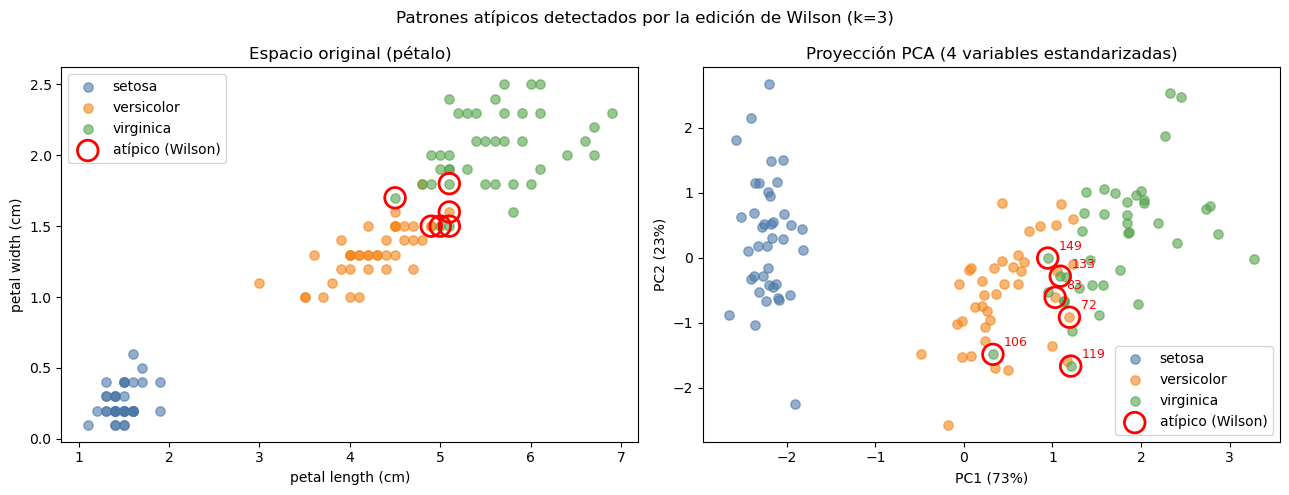

In [18]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)

colors = {0: "#4C78A8", 1: "#F58518", 2: "#54A24B"}
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Panel 1: espacio de pétalo (las variables más discriminantes)
for c in range(3):
    m = y_train == c
    axes[0].scatter(X_train[m, 2], X_train[m, 3], c=colors[c],
                    label=class_names[c], alpha=0.6, s=45)
axes[0].scatter(X_train[atypical, 2], X_train[atypical, 3],
                facecolors="none", edgecolors="red", s=220, linewidths=2,
                label="atípico (Wilson)")
axes[0].set(xlabel="petal length (cm)", ylabel="petal width (cm)",
            title="Espacio original (pétalo)")
axes[0].legend()

# Panel 2: proyección PCA del espacio estandarizado completo
for c in range(3):
    m = y_train == c
    axes[1].scatter(X_train_pca[m, 0], X_train_pca[m, 1], c=colors[c],
                    label=class_names[c], alpha=0.6, s=45)
axes[1].scatter(X_train_pca[atypical, 0], X_train_pca[atypical, 1],
                facecolors="none", edgecolors="red", s=220, linewidths=2,
                label="atípico (Wilson)")
for (px, py), fila in zip(X_train_pca[atypical], idx_train[atypical]):
    axes[1].annotate(str(fila), (px, py), textcoords="offset points",
                     xytext=(8, 6), fontsize=9, color="red")
axes[1].set(xlabel=f"PC1 ({pca.explained_variance_ratio_[0]:.0%})",
            ylabel=f"PC2 ({pca.explained_variance_ratio_[1]:.0%})",
            title="Proyección PCA (4 variables estandarizadas)")
axes[1].legend()

plt.suptitle("Patrones atípicos detectados por la edición de Wilson (k=3)")
plt.tight_layout()
plt.show()

## 4. Aplicación de la edición de Wilson

La edición consiste en **eliminar del conjunto de entrenamiento** los patrones marcados como
atípicos. El conjunto de prueba **no se toca**: sigue siendo la referencia honesta para comparar.

In [19]:
keep = ~atypical

X_train_edited = X_train_scaled[keep]
y_train_edited = y_train[keep]
idx_train_edited = idx_train[keep]

# Versión sin estandarizar, para comparar estadísticas en centímetros
X_train_raw = X[idx_train]
X_train_edited_raw = X_train_raw[keep]

print(f"Entrenamiento inicial : {X_train_scaled.shape[0]} patrones")
print(f"Entrenamiento editado : {X_train_edited.shape[0]} patrones")
print(f"Eliminados            : {atypical.sum()} ({atypical.sum() / len(y_train):.1%})")
print("Filas eliminadas del dataset original:", sorted(idx_train[atypical].tolist()))

Entrenamiento inicial : 120 patrones
Entrenamiento editado : 114 patrones
Eliminados            : 6 (5.0%)
Filas eliminadas del dataset original: [72, 83, 106, 119, 133, 149]


## 5. Comparación: dataset inicial vs. dataset editado

### 5.1 Balance de clases

In [20]:
balance = pd.DataFrame({
    "inicial": np.bincount(y_train, minlength=3),
    "editado": np.bincount(y_train_edited, minlength=3),
}, index=class_names)
balance["eliminados"] = balance["inicial"] - balance["editado"]
balance.loc["TOTAL"] = balance.sum()
balance["% eliminado"] = (balance["eliminados"] / balance["inicial"] * 100).round(1)
balance

,inicial,editado,eliminados,% eliminado
setosa,40,40,0,0.0
versicolor,40,38,2,5.0
virginica,40,36,4,10.0
TOTAL,120,114,6,5.0


El conjunto deja de estar perfectamente balanceado (40/40/40 → 40/38/36). Es el precio esperado
de la edición: se recorta justo donde hay solapamiento, así que las clases confundibles pierden
más patrones.

### 5.2 Estadísticas descriptivas por clase (en cm)

In [21]:
def stats_por_clase(A, yy, etiqueta):
    d = pd.DataFrame(A, columns=iris.feature_names)
    d["clase"] = [class_names[c] for c in yy]
    out = d.groupby("clase").agg(["mean", "std"]).round(2)
    out.columns = pd.MultiIndex.from_tuples([(a, b, etiqueta) for a, b in out.columns])
    return out

antes = stats_por_clase(X_train_raw, y_train, "inicial")
despues = stats_por_clase(X_train_edited_raw, y_train_edited, "editado")

# Ordenamos: cada variable con su media y desviación, inicial junto a editado
orden = [(v, m, e) for v in iris.feature_names
                   for m in ("mean", "std")
                   for e in ("inicial", "editado")]
stats = pd.concat([antes, despues], axis=1)[orden]
stats

sepal length (cm)                         sepal width (cm)          \
                        mean             std                     mean           
                     inicial editado inicial editado          inicial editado   
clase                                                                           
setosa                  4.99    4.99    0.31    0.31             3.42    3.42   
versicolor              5.93    5.92    0.48    0.49             2.75    2.76   
virginica               6.61    6.70    0.68    0.63             2.98    3.02   

                           petal length (cm)                          \
               std                      mean             std           
           inicial editado           inicial editado inicial editado   
clase                                                                  
setosa        0.40    0.40              1.48    1.48    0.16    0.16   
versicolor    0.31    0.31              4.25    4.21    0.44    0.42   
virginica     0.35    0.34              5.58    5.65    0.58    0.56   

           petal width (cm)                          
                       mean             std          
                    inicial editado inicial editado  
clase                                                
setosa                 0.26    0.26    0.12    0.12  
versicolor             1.32    1.31    0.19    0.18  
virginica              2.04    2.09    0.27    0.24

In [22]:
# Variabilidad total dentro de cada clase (suma de desviaciones estándar)
disp = pd.DataFrame({
    "std total inicial": [X_train_raw[y_train == c].std(axis=0).sum() for c in range(3)],
    "std total editado": [X_train_edited_raw[y_train_edited == c].std(axis=0).sum() for c in range(3)],
}, index=class_names).round(3)
disp["cambio %"] = ((disp.iloc[:, 1] / disp.iloc[:, 0] - 1) * 100).round(1)
disp

,std total inicial,std total editado,cambio %
setosa,0.971,0.971,0.0
versicolor,1.398,1.383,-1.1
virginica,1.860,1.739,-6.5


`setosa` queda intacta. `versicolor` y `virginica` reducen su dispersión y sus medias se separan
un poco más: al quitar los patrones de la frontera, cada clase se vuelve más compacta y homogénea.

### 5.3 Separabilidad de las clases

In [23]:
from sklearn.metrics import silhouette_score

sil_antes = silhouette_score(X_train_scaled, y_train)
sil_despues = silhouette_score(X_train_edited, y_train_edited)

# Solapamiento: % de patrones cuyo vecino más cercano es de otra clase
def pct_frontera(A, yy):
    _, ix = NearestNeighbors(n_neighbors=1).fit(A).kneighbors()
    return (yy[ix[:, 0]] != yy).mean() * 100

sep = pd.DataFrame({
    "silhouette (clases)": [sil_antes, sil_despues],
    "% vecino 1-NN de otra clase": [pct_frontera(X_train_scaled, y_train),
                                    pct_frontera(X_train_edited, y_train_edited)],
}, index=["inicial", "editado"]).round(3)
sep

,silhouette (clases),% vecino 1-NN de otra clase
inicial,0.390,6.667
editado,0.427,0.000


### 5.4 Impacto en el clasificador k-NN

Entrenamos el mismo k-NN con ambos conjuntos y lo evaluamos **sobre el mismo conjunto de prueba**
(30 patrones que nunca fueron editados).

In [24]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

filas = []
for k in [1, 3, 5, 7]:
    acc_i = KNeighborsClassifier(k).fit(X_train_scaled, y_train).score(X_test_scaled, y_test)
    acc_e = KNeighborsClassifier(k).fit(X_train_edited, y_train_edited).score(X_test_scaled, y_test)
    filas.append([k, acc_i, acc_e, acc_e - acc_i])

resultados = pd.DataFrame(filas, columns=["k", "acc. inicial", "acc. editado", "diferencia"]).round(4)
resultados

,k,acc. inicial,acc. editado,diferencia
0,1,0.9667,0.9333,-0.0333
1,3,0.9333,0.9667,0.0333
2,5,0.9333,0.9667,0.0333
3,7,0.9667,0.9333,-0.0333


In [25]:
k = 3
pred_i = KNeighborsClassifier(k).fit(X_train_scaled, y_train).predict(X_test_scaled)
pred_e = KNeighborsClassifier(k).fit(X_train_edited, y_train_edited).predict(X_test_scaled)

print(f"=== Matriz de confusión (k={k}), filas = real, columnas = predicho ===\n")
for nombre, pred in [("INICIAL", pred_i), ("EDITADO", pred_e)]:
    cm = pd.DataFrame(confusion_matrix(y_test, pred), index=class_names, columns=class_names)
    print(nombre, f"— accuracy {accuracy_score(y_test, pred):.4f}")
    print(cm, "\n")

=== Matriz de confusión (k=3), filas = real, columnas = predicho ===

INICIAL — accuracy 0.9333
            setosa  versicolor  virginica
setosa          10           0          0
versicolor       0          10          0
virginica        0           2          8 

EDITADO — accuracy 0.9667
            setosa  versicolor  virginica
setosa          10           0          0
versicolor       0          10          0
virginica        0           1          9 



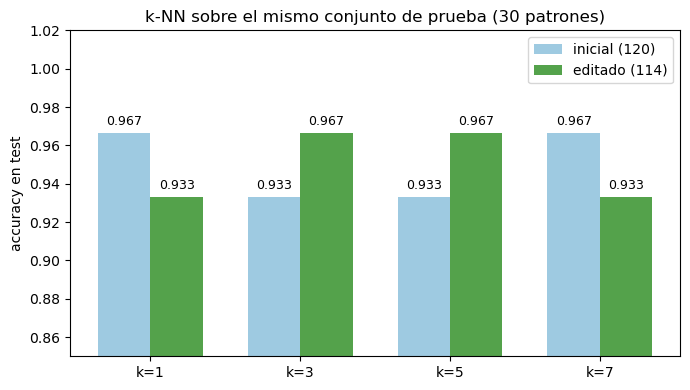

In [26]:
fig, ax = plt.subplots(figsize=(7, 4))
w = 0.35
pos = np.arange(len(resultados))
ax.bar(pos - w / 2, resultados["acc. inicial"], w, label="inicial (120)", color="#9ecae1")
ax.bar(pos + w / 2, resultados["acc. editado"], w, label="editado (114)", color="#54A24B")
for p, (a, b) in zip(pos, resultados[["acc. inicial", "acc. editado"]].values):
    ax.text(p - w / 2, a + 0.004, f"{a:.3f}", ha="center", fontsize=9)
    ax.text(p + w / 2, b + 0.004, f"{b:.3f}", ha="center", fontsize=9)
ax.set(xticks=pos, xticklabels=[f"k={k}" for k in resultados["k"]],
       ylim=(0.85, 1.02), ylabel="accuracy en test",
       title="k-NN sobre el mismo conjunto de prueba (30 patrones)")
ax.legend()
plt.tight_layout()
plt.show()

## 6. Conclusiones

**Patrones atípicos encontrados (k = 3):** 6 de 120 (5 %), ninguno de `setosa`, 2 de `versicolor`
y 4 de `virginica` — filas 72, 83, 106, 119, 133 y 149 del dataset original. Todos están en la
frontera versicolor/virginica: sus 3 vecinos más cercanos pertenecen mayoritariamente a la clase
contraria, y en promedio quedan más cerca del centroide ajeno que del propio.

**Qué cambió tras la edición:**

| Aspecto | Inicial | Editado |
|---|---|---|
| Patrones de entrenamiento | 120 | 114 |
| Balance de clases | 40 / 40 / 40 | 40 / 38 / 36 |
| Silhouette entre clases | 0.39 | 0.43 |
| % con 1-NN de otra clase | 6.7 % | 0.0 % |
| Accuracy en test (k=3) | 0.9333 | 0.9667 |

**Lectura:** la edición no cambia `setosa` (ya era separable) y actúa sólo sobre la zona de
solapamiento. El resultado es un conjunto más limpio y compacto — la frontera de decisión deja de
estar contaminada por ejemplos ruidosos — a costa de perder el balance perfecto de clases y ~5 %
de los datos.

**Advertencias honestas:**

- La ganancia en test es pequeña y depende de `k`: con k=3 y k=5 mejora (0.9333 → 0.9667, es decir
  un error menos de 30), pero con k=1 y k=7 baja. Con sólo 30 patrones de prueba, cada acierto vale
  3.3 puntos: estas diferencias no son estadísticamente significativas.
- No hay que validar el modelo editado con validación cruzada *sobre el propio conjunto editado*:
  al haber eliminado justo los casos difíciles, la métrica sube artificialmente (llega a 1.00) y
  deja de ser comparable. La comparación válida es la de la tabla anterior, contra un conjunto de
  prueba intacto.
- Iris es un dataset limpio y pequeño; la edición de Wilson luce mucho más cuando hay ruido real
  en las etiquetas.